# 4장 1강: 단순선형회귀 이론 — 실습문제

## 실습 목표

- 최소제곱법의 공식을 이용해 단순선형회귀의 기울기와 절편을 직접 계산합니다.
- 회귀계수, 예측값, 잔차, SSE, SST, 결정계수 $R^2$의 의미를 설명합니다.
- 회귀선과 잔차 플롯을 함께 확인하여 모델의 설명력과 적합 타당성을 평가합니다.

## 실습 환경 / 데이터

- Python, NumPy, pandas, Matplotlib
- `ames_housing(1).csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `YearBuilt`
- 이번 강의는 회귀 원리를 확인하는 과정이므로 회귀계수와 평가지표를 NumPy로 직접 계산합니다.

## 실습 준비

아래 셀을 실행하여 데이터를 불러오고 데이터 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_candidates = [
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적으로 매매가격을 설명하는 회귀직선 구하기

`GrLivArea`를 독립변수 $x$, `SalePrice`를 종속변수 $y$로 사용하여 최소제곱 회귀직선을 직접 구하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. $x$와 $y$의 평균을 계산하세요.
3. 아래 공식을 이용하여 기울기 $\beta_1$과 절편 $\beta_0$를 계산하세요.

$$
\beta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2},
\qquad
\beta_0 = \bar{y}-\beta_1\bar{x}
$$

4. 회귀식을 출력하고, 생활면적이 1,500일 때의 매매가격을 예측하세요.
5. 산점도 위에 회귀직선을 그리세요.

### 질문

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
-> 생활면적이 1단위 증가할 때마다 모델이 예측하는 매매가격이 평균저거으로 약 107.13만큼 증가한다는 의미

- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
-> 생활면적이 0일때  예측가격 약 18,569를 의미한다.
-> 면적이 0인 주택은 관측 범위나 현실적 분석 대상과는 거리가 있기 때문에 과도한 해석을 피해야 한다.

- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?
-> 실제값과 예측값의 차이인 잔차를 제곱해 모두 더한 SSE값이 가장 작아지는 기울기와 절편을 선택한다.


In [3]:
# 여기에 코드를 작성하세요.

import matplotlib
matplotlib.use("Agg")  # headless 환경

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("ames_housing.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# 1. 결측치 제거한 분석용 데이터
data = df[["GrLivArea", "SalePrice"]].dropna()
x = data["GrLivArea"].to_numpy(dtype=float)
y = data["SalePrice"].to_numpy(dtype=float)
print(f"원본 {len(df)}행 → 분석용 {len(data)}행 (제거 {len(df) - len(data)}행)\n")

# 2. 평균
x_bar = x.mean()
y_bar = y.mean()
print(f"x̄ (GrLivArea 평균) = {x_bar:,.4f}")
print(f"ȳ (SalePrice 평균) = {y_bar:,.4f}\n")

# 3. 최소제곱 기울기·절편 직접 계산
Sxy = ((x - x_bar) * (y - y_bar)).sum()   # 편차 곱의 합
Sxx = ((x - x_bar) ** 2).sum()            # x 편차 제곱합
beta1 = Sxy / Sxx
beta0 = y_bar - beta1 * x_bar
print(f"Sxy = {Sxy:,.2f}")
print(f"Sxx = {Sxx:,.2f}")
print(f"β1 (기울기) = {beta1:,.4f}")
print(f"β0 (절편)   = {beta0:,.4f}\n")

# scipy 결과와 대조 (검증용)
res = stats.linregress(x, y)
print(f"[검증] scipy 기울기 {res.slope:,.4f}, 절편 {res.intercept:,.4f}, "
      f"일치 {np.allclose([beta1, beta0], [res.slope, res.intercept])}\n")

# 4. 회귀식 출력 및 예측
print("[회귀식]")
print(f"SalePrice = {beta0:,.2f} + {beta1:,.2f} × GrLivArea\n")

x_new = 1500
y_pred = beta0 + beta1 * x_new
print(f"GrLivArea = {x_new:,} 일 때 예측 SalePrice = ${y_pred:,.2f}")
print(f"해석: 생활면적이 1 sq ft 늘어날 때 매매가격은 평균적으로 약 ${beta1:,.2f} 증가한다.")
print(f"      절편 ${beta0:,.2f}는 면적이 0인 경우를 뜻하므로 실질적 의미는 없다 "
      f"(데이터 범위 밖의 외삽).\n")

# 5. 산점도 + 회귀직선
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.35, s=20, edgecolors="none", label="Observations")

xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, beta0 + beta1 * xs, color="red", linewidth=2,
        label=f"y = {beta0:,.0f} + {beta1:,.2f}x")

# 예측 지점 표시
ax.scatter([x_new], [y_pred], color="darkorange", s=140, marker="X", zorder=5,
           label=f"Prediction at x={x_new:,} → ${y_pred:,.0f}")

ax.set_xlabel("GrLivArea (above ground living area, sq ft)")
ax.set_ylabel("SalePrice (USD)")
ax.set_title(f"Least Squares Regression (R² = {res.rvalue**2:.4f})")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("simple_regression.png", dpi=120)
plt.close(fig)

원본 1460행 → 분석용 1460행 (제거 0행)

x̄ (GrLivArea 평균) = 1,515.4637
ȳ (SalePrice 평균) = 180,921.1959

Sxy = 43,159,943,578.38
Sxx = 402,873,135.08
β1 (기울기) = 107.1304
β0 (절편)   = 18,569.0259

[검증] scipy 기울기 107.1304, 절편 18,569.0259, 일치 True

[회귀식]
SalePrice = 18,569.03 + 107.13 × GrLivArea

GrLivArea = 1,500 일 때 예측 SalePrice = $179,264.56
해석: 생활면적이 1 sq ft 늘어날 때 매매가격은 평균적으로 약 $107.13 증가한다.
      절편 $18,569.03는 면적이 0인 경우를 뜻하므로 실질적 의미는 없다 (데이터 범위 밖의 외삽).



---

## 필수 2. 결정계수와 잔차로 회귀모델 평가하기

필수 1에서 구한 `beta0`, `beta1`, `x`, `y`를 이용하여 모델의 설명력과 잔차 분포를 평가하세요.

### 수행 요구사항

1. 예측값 $\hat{y}$과 잔차 $e=y-\hat{y}$를 계산하세요.
2. SSE와 SST를 계산한 뒤 $R^2=1-SSE/SST$를 구하세요.
3. 잔차의 평균과 평균절대잔차(MAE)를 계산하세요.
4. 예측값을 x축, 잔차를 y축으로 하는 잔차 플롯을 그리세요. $y=0$ 기준선을 표시하세요.
5. 절대잔차가 가장 큰 관측치의 생활면적, 실제가격, 예측가격, 잔차를 출력하세요.

### 질문

- $R^2$은 이 모델에서 무엇을 의미하나요?
-> 현재 데이터에서 매매가격 전체 변동의 약 50.2%를 생활면적과의 선형회귀 모델이 설명한다는 의미

- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
-> 아닙니디. 양의 잔차와 음의 잔차가 상쇄될 수 있다. 잔차의 크기와 패턴 파악이 추가적으로 필요하다.

- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
-> 높은 예측가격 구간에서 잔차의 퍼짐이 커지는 경향과 회귀선에서 매우 멀리 떨어진 관측치가 보인다.

- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?
-> 생활면적과 가격의 양의 관계 및 약 절반의 변동성을 설명하지만, 나머지 약 49.8%는 설명하지 못했다.
-> 오차의 퍼짐과 극단값도 차이가 컸다.
-> 기본 모델로 모델링을 진행할 수 있다는 것을 확인할 수 있다.       


In [5]:
# 여기에 코드를 작성하세요.

import matplotlib
matplotlib.use("Agg")  # headless 환경

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

# ── 필수 1 결과 재현 (이미 변수가 있으면 이 블록은 생략 가능) ──────────────
df = pd.read_csv("ames_housing.csv", encoding="utf-8-sig")
df.columns = df.columns.str.strip()
data = df[["GrLivArea", "SalePrice"]].dropna()
x = data["GrLivArea"].to_numpy(dtype=float)
y = data["SalePrice"].to_numpy(dtype=float)
x_bar, y_bar = x.mean(), y.mean()
beta1 = ((x - x_bar) * (y - y_bar)).sum() / ((x - x_bar) ** 2).sum()
beta0 = y_bar - beta1 * x_bar
# ────────────────────────────────────────────────────────────────────────

# 1. 예측값과 잔차
y_hat = beta0 + beta1 * x        # 회귀직선이 말하는 값
resid = y - y_hat                # 잔차 = 실제 - 예측

# 2. SSE, SST, R^2
SSE = (resid ** 2).sum()             # 잔차제곱합 (설명 못 한 변동)
SST = ((y - y_bar) ** 2).sum()       # 총제곱합 (전체 변동)
SSR = SST - SSE                      # 회귀제곱합 (설명한 변동)
R2 = 1 - SSE / SST
print("[설명력]")
print(f"SSE = {SSE:,.2f}")
print(f"SST = {SST:,.2f}")
print(f"SSR = {SSR:,.2f}")
print(f"R²  = 1 - SSE/SST = {R2:.4f}  → SalePrice 변동의 약 {R2*100:.1f}%를 설명\n")

# 3. 잔차 평균, MAE, 추가 지표
mean_resid = resid.mean()
mae = np.abs(resid).mean()
rmse = np.sqrt(SSE / len(resid))
print("[잔차 요약]")
print(f"잔차 평균 = {mean_resid:.6e}  (최소제곱법 특성상 0에 수렴)")
print(f"MAE  = ${mae:,.2f}   (평균적으로 이만큼 빗나감)")
print(f"RMSE = ${rmse:,.2f}  (큰 오차에 더 민감한 지표)\n")

# 4. 잔차 플롯
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(y_hat, resid, alpha=0.35, s=20, edgecolors="none")
axes[0].axhline(0, color="red", linewidth=2, linestyle="--")  # y=0 기준선
axes[0].set_xlabel("Fitted values (predicted SalePrice)")
axes[0].set_ylabel("Residuals (actual - predicted)")
axes[0].set_title("Residual Plot")
axes[0].grid(alpha=0.3)

axes[1].hist(resid, bins=50, edgecolor="white")
axes[1].axvline(0, color="red", linewidth=2, linestyle="--")
axes[1].set_xlabel("Residuals")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig("residual_analysis.png", dpi=120)
plt.close(fig)

# 5. 절대잔차가 가장 큰 관측치
i_max = np.abs(resid).argmax()
print("[절대잔차 최대 관측치]")
print(f"원본 인덱스 : {data.index[i_max]}")
print(f"GrLivArea  : {x[i_max]:,.0f} sq ft")
print(f"실제 가격   : ${y[i_max]:,.2f}")
print(f"예측 가격   : ${y_hat[i_max]:,.2f}")
print(f"잔차       : ${resid[i_max]:,.2f}  ({'과대예측' if resid[i_max] < 0 else '과소예측'})\n")

# 참고: 절대잔차 상위 5개
top5 = np.argsort(-np.abs(resid))[:5]
print("[절대잔차 상위 5개]")
print(pd.DataFrame({
    "GrLivArea": x[top5],
    "Actual": y[top5],
    "Predicted": y_hat[top5].round(2),
    "Residual": resid[top5].round(2),
}, index=data.index[top5]).to_string())
print()

# 해석
print("[해석]")
print(f"1) R² = {R2:.4f}로 면적 하나만으로 가격 변동의 절반가량을 설명한다.")
print(f"   나머지 절반은 품질·입지·연식 등 모델에 없는 변수의 몫이다.")
print("2) 잔차 평균은 0이지만, 잔차 플롯에서 예측값이 커질수록 잔차의 산포가 넓어지는")
print("   깔때기 모양(이분산성)이 보인다. 등분산 가정이 위배되므로 고가 주택 구간의")
print("   예측 신뢰구간은 실제보다 좁게 계산될 수 있다.")
print("3) 잔차 분포는 오른쪽으로 긴 꼬리를 가지며, 면적이 매우 넓은데 가격은 낮은")
print("   관측치가 크게 과대예측되고 있다. 로그 변환이나 다변량 모델을 고려할 만하다.")

[설명력]
SSE = 4,584,171,086,113.13
SST = 9,207,911,334,609.98
SSR = 4,623,740,248,496.85
R²  = 1 - SSE/SST = 0.5021  → SalePrice 변동의 약 50.2%를 설명

[잔차 요약]
잔차 평균 = 1.578783e-11  (최소제곱법 특성상 0에 수렴)
MAE  = $37,638.73   (평균적으로 이만큼 빗나감)
RMSE = $56,034.30  (큰 오차에 더 민감한 지표)

[절대잔차 최대 관측치]
원본 인덱스 : 1298
GrLivArea  : 5,642 sq ft
실제 가격   : $160,000.00
예측 가격   : $622,998.51
잔차       : $-462,998.51  (과대예측)

[절대잔차 상위 5개]
      GrLivArea    Actual  Predicted   Residual
1298     5642.0  160000.0  622998.51 -462998.51
898      2364.0  611657.0  271825.19  339831.81
523      4676.0  184750.0  519510.58 -334760.58
440      2402.0  555000.0  275896.15  279103.85
691      4316.0  755000.0  480943.66  274056.34

[해석]
1) R² = 0.5021로 면적 하나만으로 가격 변동의 절반가량을 설명한다.
   나머지 절반은 품질·입지·연식 등 모델에 없는 변수의 몫이다.
2) 잔차 평균은 0이지만, 잔차 플롯에서 예측값이 커질수록 잔차의 산포가 넓어지는
   깔때기 모양(이분산성)이 보인다. 등분산 가정이 위배되므로 고가 주택 구간의
   예측 신뢰구간은 실제보다 좁게 계산될 수 있다.
3) 잔차 분포는 오른쪽으로 긴 꼬리를 가지며, 면적이 매우 넓은데 가격은 낮은
   관측치가 크게 과대예측되고 있다. 로그 변환이나 다변량 모델을 고려할 만하다.


---

## 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?
-> 기울기 : 건축연도 1년당 가격 변화, 절편 : 건축연도가 0일때 예상 가격

- $R^2$을 기준으로 모델의 설명력은 어떠한가요?
-> R^2 = 0.2734이므로 설명력이 낮다. 

- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
-> 잔차 플롯은 0을 중심으로 고르게 흩어져야 하지만 실제로는 예측값이 커질수록 잔차가 부채꼴로 벌어져
-> 등분산성 가정이 위반되었다. 또한 오차 분포가 비대칭이며, 예측값 범위가 실제 가격 범위를 전혀 덮지 못해 선형 관계 가정에도 무리가 있다.

- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.
->  예측 도구로 부적합함. 평균 6만 8천 달러씩 빗나가고 비싼 집은 맞추지 못함. 
-> 개선 방향 : 다중회귀로 확장하기. 거주면적, 전체 품질, 동네를 함께 넣으면 R^2가 크게 올라감.

> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


n = 1460,  x̄ = 1971.27,  ȳ = 180921.20
Sxy = 1,830,515,201.4,  Sxx = 1,330,922.3
기울기 b1 = 1,375.37   (건축연도 1년당 가격 변화)
절편  b0 = -2,530,308.25
회귀식: ŷ = -2,530,308.25 + 1,375.37·x

SSE = 6.6903e+12
SST = 9.2079e+12
SSR = 2.5176e+12
R²  = 0.2734  (→ SalePrice 변동의 27.3%를 설명)
잔차 표준오차 = 67,740

 YearBuilt      실제값      예측값       잔차
    2003.0 208500.0 224564.8 -16064.8
    1976.0 181500.0 187429.7  -5929.7
    2001.0 223500.0 221814.1   1685.9
    1915.0 140000.0 103531.9  36468.1
    2000.0 250000.0 220438.7  29561.3 

[예측] 2000년에 지어진 주택의 예상 매매가격 = $220,439



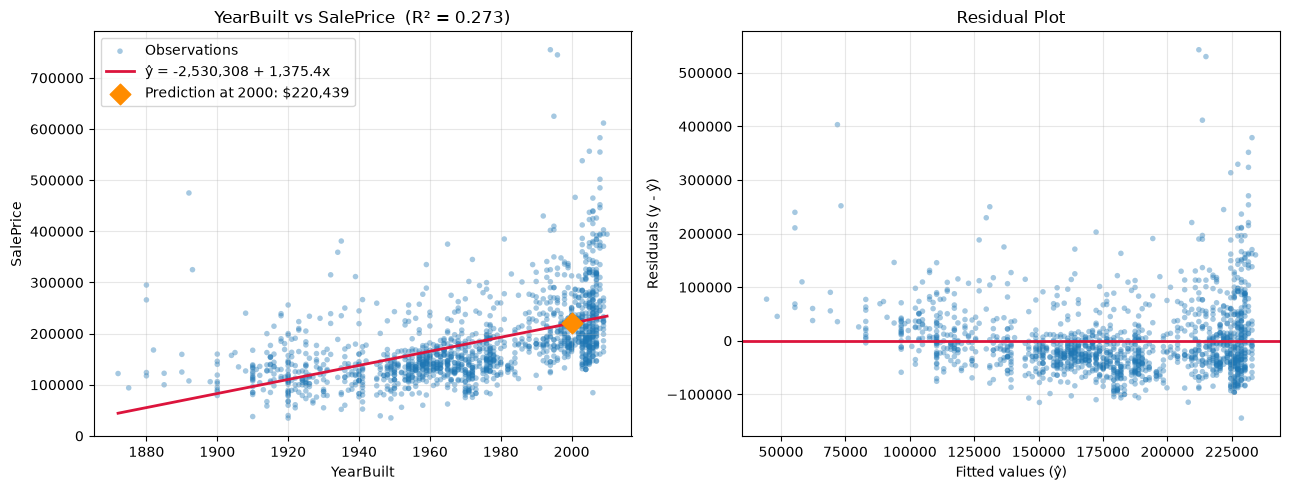

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_COL, Y_COL = "YearBuilt", "SalePrice"
X_NEW = 2000   # 3번: 예측할 건축연도

# ── 데이터 로드 (utf-8-sig: 첫 컬럼명의 BOM 제거) ──
df = pd.read_csv("ames_housing.csv", encoding="utf-8-sig")
data = df[[X_COL, Y_COL]].dropna()
x = data[X_COL].to_numpy(dtype=float)
y = data[Y_COL].to_numpy(dtype=float)
n = len(x)

# ── 1. 최소제곱법으로 기울기·절편 직접 계산 ──
#    b1 = Σ(x-x̄)(y-ȳ) / Σ(x-x̄)² ,  b0 = ȳ - b1·x̄
xbar, ybar = x.mean(), y.mean()
Sxy = ((x - xbar) * (y - ybar)).sum()
Sxx = ((x - xbar) ** 2).sum()
b1 = Sxy / Sxx
b0 = ybar - b1 * xbar

print(f"n = {n},  x̄ = {xbar:.2f},  ȳ = {ybar:.2f}")
print(f"Sxy = {Sxy:,.1f},  Sxx = {Sxx:,.1f}")
print(f"기울기 b1 = {b1:,.2f}   (건축연도 1년당 가격 변화)")
print(f"절편  b0 = {b0:,.2f}")
print(f"회귀식: ŷ = {b0:,.2f} + {b1:,.2f}·x\n")

# ── 2. 예측값, 잔차, SSE, SST, R² ──
yhat = b0 + b1 * x
resid = y - yhat
SSE = (resid ** 2).sum()          # 잔차제곱합
SST = ((y - ybar) ** 2).sum()     # 총제곱합
SSR = SST - SSE                   # 회귀제곱합
R2 = 1 - SSE / SST
RSE = np.sqrt(SSE / (n - 2))      # 잔차 표준오차

print(f"SSE = {SSE:.4e}")
print(f"SST = {SST:.4e}")
print(f"SSR = {SSR:.4e}")
print(f"R²  = {R2:.4f}  (→ {Y_COL} 변동의 {R2*100:.1f}%를 설명)")
print(f"잔차 표준오차 = {RSE:,.0f}\n")

# 앞 5개 관측치의 예측값·잔차 확인
print(pd.DataFrame({X_COL: x, "실제값": y, "예측값": yhat.round(1),
                    "잔차": resid.round(1)}).head().to_string(index=False), "\n")

# ── 3. 건축연도 2000년 주택의 가격 예측 ──
y_new = b0 + b1 * X_NEW
print(f"[예측] {X_NEW}년에 지어진 주택의 예상 매매가격 = ${y_new:,.0f}\n")

# ── 4-1. 산점도 + 회귀직선 ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(x, y, s=16, alpha=0.4, edgecolor="none", label="Observations")
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, b0 + b1 * xs, color="crimson", lw=2,
        label=f"ŷ = {b0:,.0f} + {b1:,.1f}x")
ax.scatter([X_NEW], [y_new], color="darkorange", s=110, zorder=5,
           marker="D", label=f"Prediction at {X_NEW}: ${y_new:,.0f}")
ax.set_xlabel(X_COL); ax.set_ylabel(Y_COL)
ax.set_title(f"{X_COL} vs {Y_COL}  (R² = {R2:.3f})")
ax.legend(); ax.grid(alpha=0.3)

# ── 4-2. 잔차 플롯 (예측값 대 잔차) ──
ax = axes[1]
ax.scatter(yhat, resid, s=16, alpha=0.4, edgecolor="none")
ax.axhline(0, color="crimson", lw=2)
ax.set_xlabel("Fitted values (ŷ)"); ax.set_ylabel("Residuals (y - ŷ)")
ax.set_title("Residual Plot")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("regression_plots.png", dpi=150)
plt.show()

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

$R^2$만 확인했을 때 놓칠 수 있는 점과 잔차 플롯을 추가했을 때 새롭게 확인한 내용을 중심으로 정리하세요.
